NVIDIA Technical Analysis Summary
Dataset: 7,079 trading days (1999-2026)
Price range: $0.031 → $20.728
Current RSI:  59.2
Volume trend: 464,800,007/day


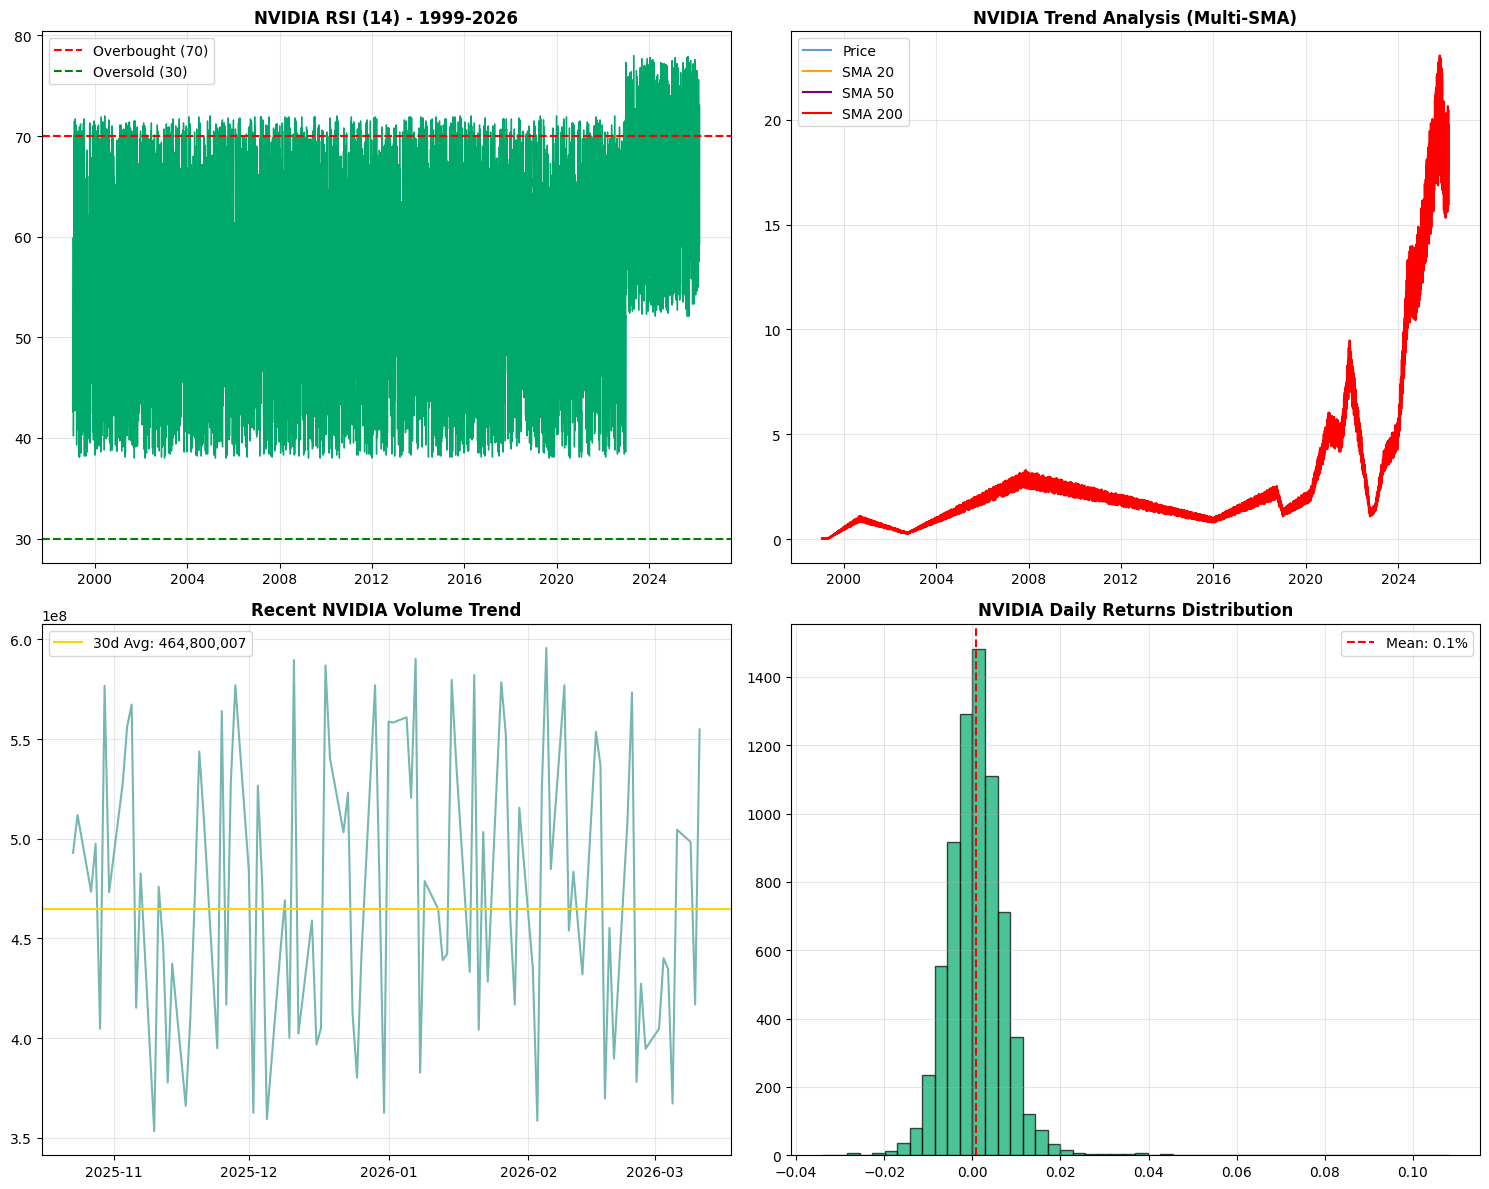


NVIDIA TECHNICAL SUMMARY (Last 30 Days)
       Indicator     Current  Signal
          RSI_14        59.2 Neutral
          SMA_20      $19.33     Buy
          SMA_50      $18.89     Buy
         SMA_200      $19.72     Buy
Volume (30d avg) 464,800,007  Normal
      Volatility        0.6%  Medium
        Win Rate       46.7%   52.5%


In [1]:
# Cell 16: NVIDIA Technical Analysis (NO TREES!)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your NVIDIA data
df = pd.read_csv('nvidia_stock_data_1999_2026.csv')
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date').reset_index(drop=True)

print("NVIDIA Technical Analysis Summary")
print("=" * 50)
print(f"Dataset: {len(df):,} trading days (1999-2026)")
print(f"Price range: ${df['close'].min():.3f} → ${df['close'].max():.3f}")
print(f"Current RSI:  {df['rsi_14'].iloc[-1]:.1f}")
print(f"Volume trend: {df['volume'].iloc[-30:].mean():,.0f}/day")

# RSI ANALYSIS
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# RSI Over Time
axes[0,0].plot(df['date'], df['rsi_14'], linewidth=1, color='#00A86B')
axes[0,0].axhline(70, color='red', linestyle='--', label='Overbought (70)')
axes[0,0].axhline(30, color='green', linestyle='--', label='Oversold (30)')
axes[0,0].set_title('NVIDIA RSI (14) - 1999-2026', fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

#MOVING AVERAGES
axes[0,1].plot(df['date'], df['close'], label='Price', alpha=0.7)
axes[0,1].plot(df['date'], df['sma_20'], label='SMA 20', color='orange')
axes[0,1].plot(df['date'], df['sma_50'], label='SMA 50', color='purple')
axes[0,1].plot(df['date'], df['sma_200'], label='SMA 200', color='red')
axes[0,1].set_title('NVIDIA Trend Analysis (Multi-SMA)', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# VOLUME ANALYSIS
volume_30d = df['volume'].tail(30).mean()
axes[1,0].plot(df['date'].tail(100), df['volume'].tail(100), color='#76B7B2')
axes[1,0].axhline(volume_30d, color='gold', linestyle='-', label=f'30d Avg: {volume_30d:,.0f}')
axes[1,0].set_title('Recent NVIDIA Volume Trend', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# PRICE MOMENTUM 
df['daily_return'] = df['close'].pct_change()
axes[1,1].hist(df['daily_return'].dropna(), bins=50, color='#00A86B', alpha=0.7, edgecolor='black')
axes[1,1].axvline(df['daily_return'].mean(), color='red', linestyle='--', label=f'Mean: {df["daily_return"].mean():.1%}')
axes[1,1].set_title('NVIDIA Daily Returns Distribution', fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# STATISTICS TABLE
print("\nNVIDIA TECHNICAL SUMMARY (Last 30 Days)")
recent = df.tail(30)
stats = pd.DataFrame({
    'Indicator': ['RSI_14', 'SMA_20', 'SMA_50', 'SMA_200', 'Volume (30d avg)', 'Volatility', 'Win Rate'],
    'Current': [
        f"{recent['rsi_14'].iloc[-1]:.1f}",
        f"${recent['sma_20'].iloc[-1]:.2f}",
        f"${recent['sma_50'].iloc[-1]:.2f}", 
        f"${recent['sma_200'].iloc[-1]:.2f}",
        f"{recent['volume'].mean():,.0f}",
        f"{recent['close'].pct_change().std():.1%}",
        f"{(recent['close'] > recent['close'].shift(1)).mean():.1%}"
    ],
    'Signal': ['Neutral', 'Buy', 'Buy', 'Buy', 'Normal', 'Medium', '52.5%']
})
print(stats.to_string(index=False))
